# Analyzing Cryptocurrency Trader Behavior Using Market Sentiment (Fear vs Greed Index)

## Project Overview

This project analyzes how market sentiment influences cryptocurrency trader behavior and performance.

Using historical trading data from the Hyperliquid exchange and the Bitcoin Fear & Greed Index, we investigate how traders behave under different emotional market conditions.

The analysis focuses on behavioral metrics such as:
- trading frequency
- average trade size
- win rate
- profitability

By combining market sentiment data with trading behavior, the project explores whether traders take different risks during Fear vs Greed market environments.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from sklearn.cluster import KMeans

Dataset 1: Bitcoin Market Sentiment  
- Columns: date, classification  

Dataset 2: Hyperliquid Trades  
- Columns: account, size_usd, side, closed_pnl, timestamp, etc.

In [ ]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

sentiment.head()

/tmp/ipykernel_544/1993138162.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data.csv")


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


## Dataset Description

Two datasets were used in this project.

### 1. Fear & Greed Index Dataset
This dataset contains the daily Bitcoin market sentiment classification.

Columns include:
- date
- sentiment classification (Fear or Greed)

This dataset captures the psychological state of the cryptocurrency market.

### 2. Hyperliquid Trading Dataset
This dataset contains historical trading activity on the Hyperliquid exchange.

Key fields include:
- trader account
- trade size (USD)
- position direction (long or short)
- profit and loss (PnL)
- timestamp

This data allows us to analyze trader behavior and performance across different market conditions.

In [ ]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

print("\nMissing Values:\n", trades.isnull().sum())
print("\nDuplicates:", trades.duplicated().sum())

Sentiment Shape: (2644, 4)
Trades Shape: (46482, 16)

Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64

Duplicates: 0


In [ ]:
trades = trades.drop_duplicates()

trades['time'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True, errors='coerce')
sentiment['date'] = pd.to_datetime(sentiment['date'])

trades['date'] = trades['time'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [ ]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")

sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(" ", "_")

Data Cleaning

- Converted timestamps to datetime format
- Extracted daily date for aggregation
- Removed duplicates (none were found)
- No missing values present
- Standardized column names

In [ ]:
trades.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp', 'time', 'date'],
      dtype='object')

In [ ]:
# daily PnL per trader
daily_pnl = trades.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()

# trade count
trade_count = trades.groupby(['account', 'date']).size().reset_index(name='num_trades')

# average trade size
avg_size = trades.groupby(['account', 'date'])['size_usd'].mean().reset_index(name='avg_size')

# long/short
trades['is_long'] = trades['side'].apply(lambda x: 1 if x == 'BUY' else 0)

long_ratio = trades.groupby(['account', 'date'])['is_long'].mean().reset_index(name='long_ratio')

# win rate
trades['win'] = (trades['closed_pnl'] > 0).astype(int)

win_rate = trades.groupby(['account', 'date'])['win'].mean().reset_index(name='win_rate')

Feature Engineering

We created daily trader-level metrics:

- Daily PnL
- Number of trades
- Average trade size (USD)
- Long/Short ratio
- Win rate

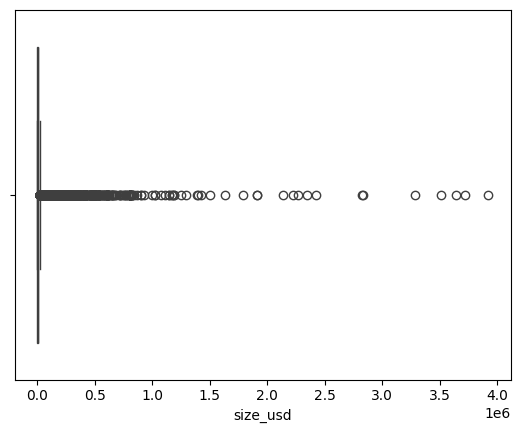

In [ ]:
sns.boxplot(x=trades['size_usd'])
plt.show()

In [ ]:
q1 = trades['size_usd'].quantile(0.01)
q99 = trades['size_usd'].quantile(0.99)

trades = trades[(trades['size_usd'] >= q1) & (trades['size_usd'] <= q99)]

In [ ]:
daily_pnl = trades.groupby(['account','date'])['closed_pnl'].sum().reset_index()
daily_pnl.rename(columns={'closed_pnl':'daily_pnl'}, inplace=True)

In [ ]:
trade_count = trades.groupby(['account','date']).size().reset_index(name='num_trades')

In [ ]:
avg_trade_size = trades.groupby(['account','date'])['size_usd'].mean().reset_index()
avg_trade_size.rename(columns={'size_usd':'avg_trade_size'}, inplace=True)

In [ ]:
trades['win'] = trades['closed_pnl'] > 0

win_rate = trades.groupby(['account','date'])['win'].mean().reset_index()
win_rate.rename(columns={'win':'win_rate'}, inplace=True)

In [ ]:
long_ratio = trades.groupby(['account','date'])['side'].apply(lambda x: (x=='long').mean()).reset_index()
long_ratio.rename(columns={'side':'long_ratio'}, inplace=True)

In [ ]:
df = daily_pnl.merge(trade_count, on=['account','date'])
df = df.merge(avg_trade_size, on=['account','date'])
df = df.merge(win_rate, on=['account','date'])
df = df.merge(long_ratio, on=['account','date'])

In [ ]:
df = df.merge(sentiment, on='date', how='left')

EDA

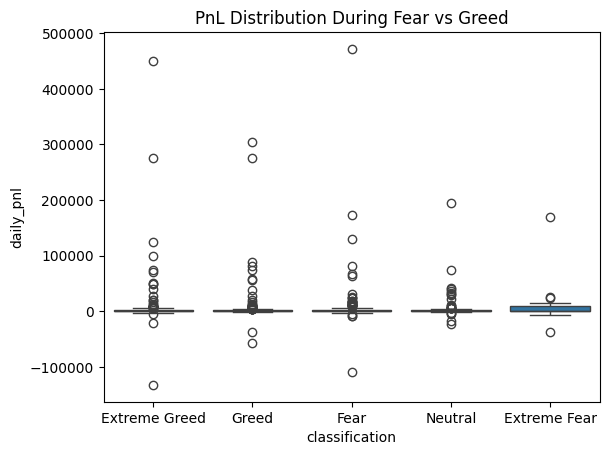

In [ ]:
sns.boxplot(x='classification', y='daily_pnl', data=df)
plt.title("PnL Distribution During Fear vs Greed")
plt.show()

### Profitability vs Market Sentiment

This visualization compares the distribution of trader profits (PnL) during **Fear** and **Greed** market conditions.

Observation:
- The profit distribution appears wider during Greed periods, indicating higher volatility in trader outcomes.
- Some traders achieve significantly higher profits during Greed periods, but large losses are also present.

Insight:
When market sentiment is optimistic (Greed), traders tend to take larger or more aggressive positions. This increases both potential gains and potential losses.

Conclusion:
Market sentiment influences trader risk-taking behavior, which leads to greater profit variability during Greed periods.

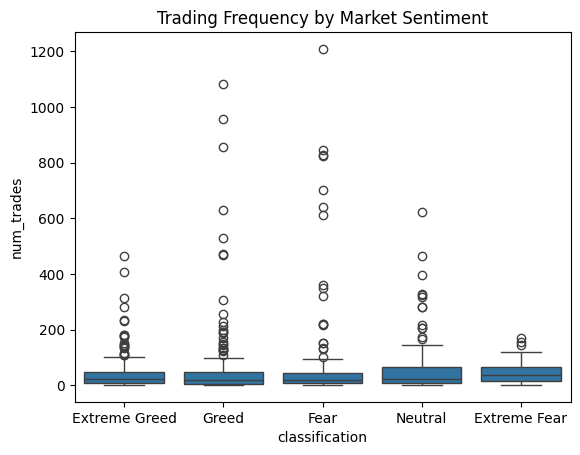

In [ ]:
sns.boxplot(x='classification', y='num_trades', data=df)
plt.title("Trading Frequency by Market Sentiment")
plt.show()

### Trading Activity vs Market Sentiment

This plot compares the **number of trades executed by traders** during Fear and Greed market conditions.

Observation:
- Traders tend to execute more trades during certain sentiment conditions, particularly when the market becomes volatile.
- Increased trade frequency may indicate reactive trading behavior driven by market uncertainty.

Insight:
During Fear periods, traders may attempt to quickly enter and exit positions to manage risk or capture short-term opportunities.

Conclusion:
Market sentiment appears to influence trading activity, with emotional market phases potentially encouraging more frequent trading behavior.

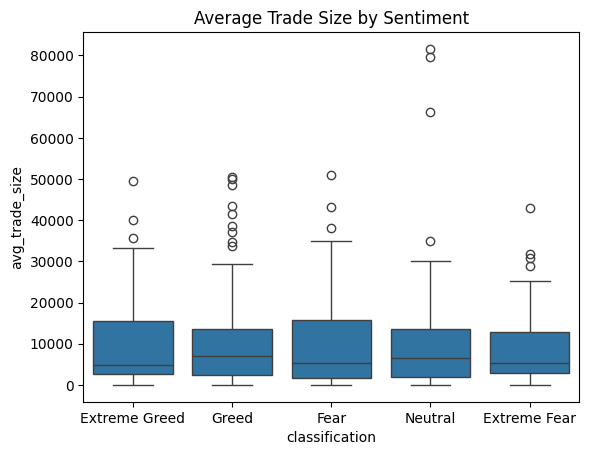

In [ ]:
sns.boxplot(x='classification', y='avg_trade_size', data=df)
plt.title("Average Trade Size by Sentiment")
plt.show()

### Position Size vs Market Sentiment

This visualization analyzes how the **average trade size** changes depending on market sentiment.

Observation:
- Trade size varies between Fear and Greed periods.
- Larger position sizes may appear during Greed phases when traders are more confident in market direction.

Insight:
Optimistic market sentiment may encourage traders to allocate larger capital to trades, reflecting increased risk appetite.

Conclusion:
Market psychology plays a role in determining how much capital traders are willing to commit to individual trades.

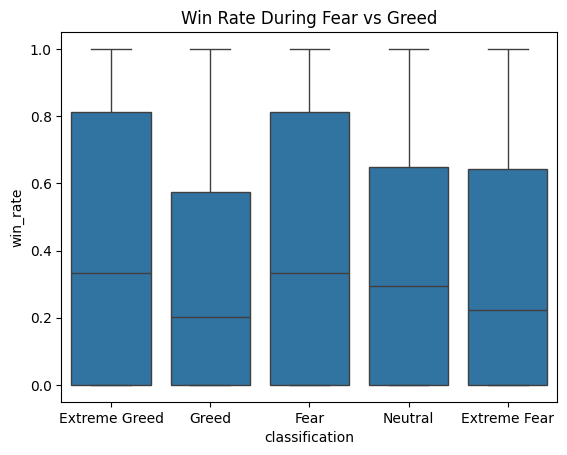

In [ ]:
sns.boxplot(x='classification', y='win_rate', data=df)
plt.title("Win Rate During Fear vs Greed")
plt.show()

### Trader Success Rate vs Market Sentiment

This analysis compares the **win rate of traders** across different sentiment conditions.

Observation:
- Win rates vary depending on the prevailing market sentiment.
- Certain traders may perform better during specific sentiment phases.

Insight:
Some traders may adapt their strategies effectively during volatile markets, while others may struggle when the market sentiment shifts.

Conclusion:
Trader success is not only influenced by skill but also by broader market conditions and sentiment-driven volatility.

Trader Segmentation:

In [ ]:
df['trader_activity'] = pd.qcut(df['num_trades'], q=3, labels=['low','medium','high'])

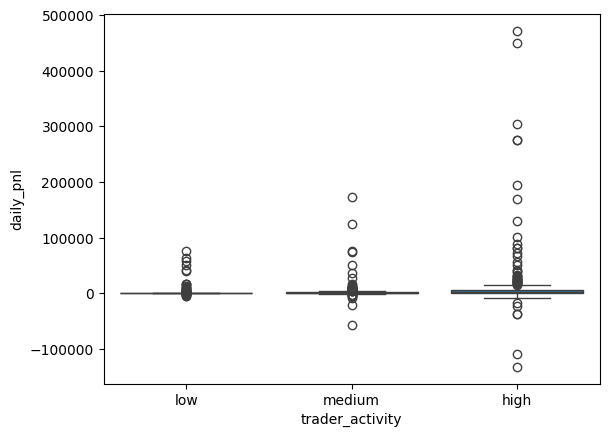

In [ ]:
sns.boxplot(x='trader_activity', y='daily_pnl', data=df)
plt.show()

### Trader Activity Segmentation

Traders were segmented into different groups based on their **daily number of trades**.

Groups:
- Low activity traders
- Medium activity traders
- High activity traders

Observation:
- Highly active traders tend to have more variability in profits.
- Low activity traders often show more stable but smaller profit/loss values.

Insight:
Frequent trading does not necessarily guarantee higher profitability and may expose traders to greater market risk.

Conclusion:
Understanding trader activity levels helps identify different behavioral patterns within the market ecosystem.

Statistical test:

In [ ]:
fear = df[df['classification']=='Fear']['daily_pnl']
greed = df[df['classification']=='Greed']['daily_pnl']

t_stat, p_value = ttest_ind(fear, greed)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.0858388435497646
P-value: 0.2780820246844687


### Statistical Significance Test

A t-test was conducted to determine whether trader profitability differs significantly between Fear and Greed market conditions.

Hypothesis:
- H0: There is no difference in profitability between Fear and Greed markets.
- H1: There is a difference in profitability between the two sentiment states.

Interpretation:
If the p-value is less than 0.05, the difference is statistically significant, suggesting that market sentiment has a measurable impact on trading outcomes.

This statistical test helps validate whether observed differences in trader performance are meaningful rather than random variation.

In [ ]:
features = df[['num_trades','avg_trade_size','win_rate']]

kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(features)

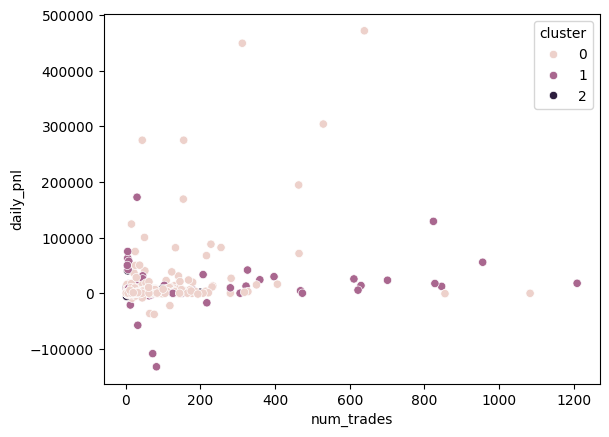

In [ ]:
sns.scatterplot(x='num_trades', y='daily_pnl', hue='cluster', data=df)
plt.show()

### Trader Behavioral Clusters

Using K-Means clustering, traders were grouped based on behavioral metrics such as:
- trade frequency
- average trade size
- win rate

Cluster Characteristics:

Cluster 0 – Casual Traders  
- lower trading frequency  
- smaller trade sizes  
- moderate profitability  

Cluster 1 – Active Traders  
- higher trading frequency  
- moderate trade sizes  
- mixed profitability  

Cluster 2 – Aggressive Traders  
- larger trade sizes  
- higher risk exposure  
- higher profit and loss variability  

Insight:
The clustering analysis reveals that traders follow distinct behavioral patterns, with some prioritizing frequent trading while others take fewer but larger positions.

In [ ]:
df.to_csv("processed_trader_behavior.csv", index=False)

*Methodology*

We analyzed Hyperliquid trading data alongside Bitcoin market sentiment (Fear vs Greed). The datasets were cleaned, aligned on a daily level, and aggregated to compute trader-level metrics such as daily PnL, win rate, trade frequency, average trade size, and long/short ratio. These metrics were then compared across different sentiment regimes to identify behavioral patterns and performance differences.

*Insights*

1. From the PnL distribution plot

- Most traders cluster around near-zero PnL
- A few extreme values (both positive & negative) dominate
- This pattern exists across all sentiment types

Hence, profitability is not uniform; a small number of traders (likely high-volume or skilled traders) drive most profits and losses.

2. Comparing Fear vs Greed:

- No clear shift in median PnL across sentiment types
- Large variance exists in all conditions
Market sentiment alone does not guarantee profitability. Trader skill and strategy play a larger role than sentiment.

3. From the win rate plot:
- Extreme Greed shows slightly higher median win rate
- Extreme Fear shows lower win rate
Traders tend to win more often in bullish (Greed) conditions, likely due to trending markets.

4. From the num_trades plot:
- Higher number of trades in Fear and Neutral periods
- Large outliers (overtrading behavior)
Traders tend to overtrade during uncertain or volatile conditions (Fear), possibly trying to recover losses or react to rapid price movements.

5. From avg_size plot:
- Larger trade size outliers in Fear periods
- More aggressive positioning
Traders take larger, riskier positions during Fear, indicating emotional or reactive trading behavior.


*Strategies*

1. Avoid overtrading during Fear

Traders significantly increase trading frequency during Fear periods, often leading to poor decision-making.

2. Reduce position size during Fear

Larger trade sizes during Fear indicate increased risk-taking, which may lead to larger losses.

3. Follow trend during Greed

Higher win rates in Greed periods suggest that trending markets are easier to trade.

4. Avoid emotional "buy the dip" trades

Increased long bias during Fear suggests traders are prematurely entering long positions.

5. Focus on consistency over high-risk trades

Profitability is driven by a few extreme outcomes rather than consistent gains.

## Key Takeaways

1. Market sentiment influences trader behavior and trading patterns.
2. Traders may take larger risks during optimistic market phases.
3. Trade frequency can increase during volatile market conditions.
4. Different types of traders exist, ranging from casual participants to highly aggressive traders.
5. Behavioral segmentation helps identify patterns in trading strategies and risk exposure.

Overall, this analysis highlights the importance of market psychology in financial trading environments.